# Does heavy-chain germline AA affect light-chain pairing, specifcally at entrecnhed sites?

## Motivation

We've shown within v family entrenched sites have contact with the light chain, and we suggest that epistatic interactions between these sites and the light chains exist.
We wanted to see whether their gemrline identity effects light chain pairing.
The entrenched sites contact the light chain CDR3, so there isn't a simple categorical varaible that explains this, so we tested the following descriptors:

## LC descriptors tested

| Descriptor | Categories | Description |
|---|---|---|
| **κ/λ type** | 2 | Light chain isotype |
| **VL family** | ~15 | V-gene family of the light chain |
| **J gene (all)** | ~9 | Light-chain J gene |
| **CDR3 length** | ~10–17 | Light-chain CDR3 length (codons) |
| **J gene (κ only)** | ~5 | J gene within κ-paired families only |
| **J gene (λ only)** | ~4 | J gene within λ-paired families only |
| **CDR3 length (κ only)** | ~8 | CDR3 length within κ-paired families |
| **CDR3 length (λ only)** | ~7 | CDR3 length within λ-paired families |

## Methods

**Per-(V family, site) scan**: For each (V family, site) with germline-AA variation,
build a k×m contingency table (k germline AAs × m LC categories) and compute Cramér's V.
Significance is assessed via permutation test (1000 permutations, BH correction).

**Per-comparison-pair analysis**: For each AA pair from the entrenchment analysis, build
a 2×m table (AA1 vs AA2 × LC categories) and compute Cramér's V with χ² p-value.
Compare effect sizes between entrenched and non-entrenched pairs using Mann-Whitney U.

**Same-site control**: Restrict the comparison to (site, V family) combinations that
contain at least one entrenched pair. This controls for site-level differences in
germline diversity: since germline AA is deterministic given the V gene, a site that
doesn't affect pairing can still show bias simply because it's linked to another site
on the same gene that does. Sites with more germline AA variation (which entrenched
sites tend to have, since entrenchment requires at least two AAs) may show higher
Cramér's V for this reason.

## Key results

### Per-site scan: pairing bias is pervasive

Most heavy-chain sites show significant association with LC descriptors (BH < 0.05):

| Descriptor | Significant / tested |
|---|---|
| κ/λ type | 100 / 120 (83%) |
| VL family | 107 / 120 (89%) |
| J gene | 95 / 120 (79%) |
| CDR3 length | 78 / 120 (65%) |

All 10 entrenched (site, V family) pairs are significant for κ/λ, VL family, and J gene;
8/10 are significant for CDR3 length.

### Entrenched pairs show stronger pairing bias — but only across sites

Comparing Cramér's V between entrenched and non-entrenched AA pairs (Mann-Whitney,
one-sided):

| Descriptor | MW p-value | Entrenched > non-entrenched? |
|---|---|---|
| VL family | 0.010 | ✓ |
| J gene (all) | 0.015 | ✓ |
| J gene (κ) | 0.008 | ✓ |
| CDR3 length | 0.018 | ✓ |
| CDR3 length (κ) | 0.002 | ✓ |
| κ/λ type | 0.052 | marginal |
| J gene (λ) | 0.47 | ✗ |
| CDR3 length (λ) | 0.43 | ✗ |

Lambda-side descriptors show no enrichment, consistent with the signal being driven
by κ-associated variation.

### Same-site control: all effects vanish

When restricting to non-entrenched pairs **at the same (site, V family)** as entrenched
pairs, all Mann-Whitney p-values exceed 0.05 (range: 0.10–0.82). At any given site,
entrenched and non-entrenched AA pairs show comparable association with LC descriptors.
The across-site signal likely reflects that entrenched pairs occur at sites with higher
germline diversity, which can inflate pairing bias through V-gene linkage even without
a causal effect on pairing.

## Conclusions

1. **Heavy-chain germline AA strongly predicts light-chain properties** across most sites
   and V families. This is expected given that V genes co-segregate with LC pairing
   preferences in the naive repertoire.

2. **Entrenched AA pairs show stronger LC pairing bias than non-entrenched pairs** when
   compared across all sites, but this effect **vanishes in the same-site control**:
   at any given site, entrenched pairs do not show stronger pairing bias than
   non-entrenched pairs. This is likely driven by site-level differences in germline
   diversity rather than residue-specific pairing effects.

3. **These results do not contradict the hypothesis that epistasis with the light chain contributes to entrenchment at these sites. The interface involves the most diverse regions of both proteins (high-germline-diversity heavy-chain sites contacting the light-chain CDR3), making it inherently difficult to capture residue-level epistasis through categorical descriptors in a repertoire-level analysis.**

## 1. Data loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob as glob_mod

from scipy.stats import chi2_contingency, mannwhitneyu, fisher_exact
from statsmodels.stats.multitest import multipletests
from dnsmex.dxsm_data import dataset_dict

plt.rcParams['figure.dpi'] = 110

# --- Load extended LC annotations (VL family, J gene, CDR3 length) ---
paired_df = pd.read_csv(
    dataset_dict['v1jaffePaired'],
    usecols=['sample_id', 'family', 'v_gene_heavy', 'v_gene_light',
             'j_gene_light', 'light_chain_type',
             'cdr3_codon_start_light', 'cdr3_codon_end_light']
)
family_info = (
    paired_df
    .groupby(['sample_id', 'family'])
    .agg(v_gene=('v_gene_heavy', 'first'),
         v_gene_light=('v_gene_light', 'first'),
         j_gene_light=('j_gene_light', 'first'),
         light_chain_type=('light_chain_type', 'first'),
         cdr3_start=('cdr3_codon_start_light', 'first'),
         cdr3_end=('cdr3_codon_end_light', 'first'))
    .reset_index()
)
family_info['v_family'] = family_info['v_gene'].str.extract(r'^(IGHV\d+)')
family_info['vl_family'] = family_info['v_gene_light'].str.extract(r'^(IG[KL]V\d+)')
family_info['cdr3_len'] = family_info['cdr3_end'] - family_info['cdr3_start']

# --- Germline AA at each site, pivoted to wide germ_{site} columns ---
germline_codons = pd.read_csv('germline/germline_codons_chothia.csv')
germline_wide = germline_codons.pivot_table(
    index='v_gene', columns='site', values='amino_acid', aggfunc='first'
)
germline_wide.columns = [f'germ_{s}' for s in germline_wide.columns]
germline_wide = germline_wide.reset_index()

families = family_info.merge(germline_wide, on='v_gene', how='left')
germ_cols = [c for c in families.columns if c.startswith('germ_')]
families = families.dropna(subset=germ_cols[:1])
sites_all = [c.removeprefix('germ_') for c in germ_cols]

print(f"Loaded {len(families):,} families with extended LC annotations.")
print(f"  \u03ba: {(families.light_chain_type == 'kappa').sum():,}")
print(f"  \u03bb: {(families.light_chain_type == 'lambda').sum():,}")
print(f"  Baseline \u03ba fraction: {(families.light_chain_type == 'kappa').mean():.3f}")
print(f"  Sites with germline-AA data: {len(sites_all)}")
print(f"  VL families: {families.vl_family.nunique()}")
print(f"  J genes: {families.j_gene_light.nunique()}")
print(f"  CDR3 lengths: {families.cdr3_len.nunique()} unique values")

Loaded 51,319 families with extended LC annotations.
  κ: 31,625
  λ: 19,694
  Baseline κ fraction: 0.616
  Sites with germline-AA data: 102
  VL families: 16
  J genes: 9
  CDR3 lengths: 17 unique values


In [2]:
# --- Load entrenched-site annotations ---
try:
    from utils import load_entrenched_sites
    _, _, _, _, within_dfs, _ = load_entrenched_sites('chothia')
    within_dfs['site'] = within_dfs['site'].astype(str)
    entrenched_pairs = set(zip(within_dfs['site'], within_dfs['v_family']))
    print(f"Loaded {len(entrenched_pairs)} entrenched (site, V family) pairs.")
except Exception as e:
    entrenched_pairs = set()
    print(f"Entrenched site annotations unavailable: {e}")

# --- Load comparison pairs for per-pair analysis ---
comp_files = sorted(glob_mod.glob('_output/entrenchment_analysis/chothia/comparison_within_*.csv'))
comp_dfs = []
for f in comp_files:
    df = pd.read_csv(f)
    comp_dfs.append(df)
    print(f"  {f}: {len(df)} rows")
comp_all = pd.concat(comp_dfs, ignore_index=True)
print(f"Total comparison rows (including A\u2192B and B\u2192A): {len(comp_all)}")

# Deduplicate: keep only one direction per pair (alphabetically first AA as aa1)
comp_all['aa1'] = comp_all['parent_aa_1_and_target_aa_2']
comp_all['aa2'] = comp_all['parent_aa_2_and_target_aa_1']
comp_all['site'] = comp_all['site'].astype(str)
comp_all['v_family'] = comp_all['v_family_1']

comp = comp_all[comp_all['aa1'] < comp_all['aa2']].copy()
comp = comp[comp['v_family'].isin(['IGHV1', 'IGHV3'])].copy()
print(f"Unique pairs (deduplicated, IGHV1+IGHV3 only): {len(comp)}")
print(f"  Entrenched: {comp['is_entrenched'].sum()}")
print(f"  Non-entrenched: {(~comp['is_entrenched']).sum()}")

Loaded 10 entrenched (site, V family) pairs.
  _output/entrenchment_analysis/chothia/comparison_within_IGHV1.csv: 190 rows
  _output/entrenchment_analysis/chothia/comparison_within_IGHV3.csv: 260 rows
  _output/entrenchment_analysis/chothia/comparison_within_IGHV4.csv: 68 rows
Total comparison rows (including A→B and B→A): 518
Unique pairs (deduplicated, IGHV1+IGHV3 only): 225
  Entrenched: 19
  Non-entrenched: 206


## 2. Per-(V family, site) scan: Cramér's V for all LC descriptors

For each V family and each site with germline-AA variation, build a contingency table
of (germline AAs) × (LC descriptor categories) and compute Cramér's V. Significance is
assessed via a permutation test (shuffle LC labels within V family, 1000 permutations).

All descriptors use the same framework, including κ/λ (which is just a 2-column
contingency table).

In [3]:
# --- Helper functions ---

rng = np.random.default_rng(42)

def cramers_v(contingency_table):
    """Compute Cram\u00e9r's V from a contingency table (numpy array)."""
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum()
    min_dim = min(contingency_table.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min_dim))


def scan_site_multicat(fams_sub, site, lc_col, min_per_cell=5):
    """
    Test whether germline AA at `site` predicts the categorical LC descriptor `lc_col`.
    Returns Cram\u00e9r's V and a permutation p-value.
    """
    germ_col = f'germ_{site}'
    if germ_col not in fams_sub.columns:
        return None
    sub = fams_sub[[germ_col, lc_col]].dropna()
    if len(sub) < 50:
        return None

    # Build contingency table, filter rare categories
    ctab = pd.crosstab(sub[germ_col], sub[lc_col])
    ctab = ctab[ctab.sum(axis=1) >= min_per_cell]
    ctab = ctab.loc[:, ctab.sum(axis=0) >= min_per_cell]
    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        return None

    obs_v = cramers_v(ctab.values)

    # Permutation test: shuffle LC labels, recompute Cram\u00e9r's V
    n = int(ctab.values.sum())
    row_labels = np.repeat(np.arange(ctab.shape[0]), ctab.values.sum(axis=1).astype(int))
    col_labels = np.concatenate([
        np.concatenate([np.full(int(ctab.values[i, j]), j)
                        for j in range(ctab.shape[1])])
        for i in range(ctab.shape[0])
    ])

    N_PERM_LOCAL = 1000
    perm_vs = np.empty(N_PERM_LOCAL)
    for p in range(N_PERM_LOCAL):
        shuffled_cols = col_labels[rng.permutation(n)]
        perm_tab = np.zeros_like(ctab.values)
        for i in range(ctab.shape[0]):
            mask_i = row_labels == i
            counts = np.bincount(shuffled_cols[mask_i], minlength=ctab.shape[1])
            perm_tab[i, :] = counts
        perm_vs[p] = cramers_v(perm_tab)

    p_perm = float(((perm_vs >= obs_v).sum() + 1) / (N_PERM_LOCAL + 1))

    return {
        'site': site,
        'n_germ_aas': int(ctab.shape[0]),
        'n_lc_cats': int(ctab.shape[1]),
        'n_families': n,
        'cramers_v': obs_v,
        'p_perm': p_perm,
    }

In [4]:
# --- Run scan for each LC descriptor ---

V_FAMILIES_SCAN = sorted([
    vf for vf in families.v_family.dropna().unique()
    if (families.v_family == vf).sum() >= 100
])
print(f"Scanning V families with >=100 families: {V_FAMILIES_SCAN}")

lc_descriptors = {
    'lc_type': 'light_chain_type',
    'vl_family': 'vl_family',
    'j_gene_light': 'j_gene_light',
    'cdr3_len': 'cdr3_len',
}

scan_results = {}
for desc_name, desc_col in lc_descriptors.items():
    print(f"\n{'='*60}")
    print(f"Scanning: germline AA \u00d7 {desc_name}")
    print(f"{'='*60}")
    rows = []
    for vf in ['IGHV1', 'IGHV3', 'IGHV4']:
        vf_fams = families[families.v_family == vf]
        for site in sites_all:
            r = scan_site_multicat(vf_fams, site, desc_col)
            if r is not None:
                r['v_family'] = vf
                rows.append(r)
    df = pd.DataFrame(rows)
    if len(df) > 0:
        _, p_bh, _, _ = multipletests(df['p_perm'], method='fdr_bh')
        df['p_bh'] = p_bh
        df = df.sort_values('p_perm').reset_index(drop=True)
    scan_results[desc_name] = df
    print(f"  (V family, site) cells tested: {len(df)}")
    print(f"  BH<0.05: {(df['p_bh'] < 0.05).sum()}")
    if len(df) > 0:
        print(f"  Cram\u00e9r's V range: {df['cramers_v'].min():.4f} \u2013 {df['cramers_v'].max():.4f}")
        print(f"  Top 10:")
        print(df.head(10)[['v_family', 'site', 'n_germ_aas', 'n_lc_cats',
                            'n_families', 'cramers_v', 'p_perm', 'p_bh']].round(4).to_string(index=False))

Scanning V families with >=100 families: ['IGHV1', 'IGHV2', 'IGHV3', 'IGHV4', 'IGHV5', 'IGHV6', 'IGHV7']

Scanning: germline AA × lc_type


  (V family, site) cells tested: 120
  BH<0.05: 100
  Cramér's V range: 0.0014 – 0.1454
  Top 10:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV1   16           3          2        6041     0.0759   0.001 0.0016
   IGHV1   27           3          2        6041     0.0759   0.001 0.0016
   IGHV1   33           6          2        6041     0.1115   0.001 0.0016
   IGHV1   41           3          2        6041     0.0467   0.001 0.0016
   IGHV1   34           3          2        6041     0.0533   0.001 0.0016
   IGHV1   35           4          2        6041     0.0803   0.001 0.0016
   IGHV1   30           2          2        6041     0.0717   0.001 0.0016
   IGHV1   50           5          2        6041     0.0997   0.001 0.0016
   IGHV1   54           6          2        6041     0.1155   0.001 0.0016
   IGHV1   56           6          2        6041     0.1080   0.001 0.0016

Scanning: germline AA × vl_family


  (V family, site) cells tested: 120
  BH<0.05: 107
  Cramér's V range: 0.0223 – 0.2325
  Top 10:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV1   34           3         15        6037     0.1211   0.001 0.0013
   IGHV1   33           6         15        6037     0.1355   0.001 0.0013
   IGHV1   35           4         15        6037     0.1598   0.001 0.0013
   IGHV1   41           3         15        6037     0.1666   0.001 0.0013
   IGHV1   31           4         15        6037     0.0963   0.001 0.0013
   IGHV1   30           2         15        6037     0.1118   0.001 0.0013
   IGHV1   63           2         15        6037     0.0927   0.001 0.0013
   IGHV1   60           2         15        6037     0.1035   0.001 0.0013
   IGHV1   54           6         15        6037     0.1008   0.001 0.0013
   IGHV1   56           6         15        6037     0.1042   0.001 0.0013

Scanning: germline AA × j_gene_light


  (V family, site) cells tested: 120
  BH<0.05: 95
  Cramér's V range: 0.0179 – 0.1961
  Top 10:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV1   33           6          9        6041     0.0685   0.001 0.0016
   IGHV1   35           4          9        6041     0.0695   0.001 0.0016
   IGHV1   30           2          9        6041     0.0896   0.001 0.0016
   IGHV1   58           5          9        6041     0.0694   0.001 0.0016
   IGHV1   54           6          9        6041     0.0729   0.001 0.0016
   IGHV1   56           6          9        6041     0.0683   0.001 0.0016
   IGHV1   57           2          9        6041     0.0896   0.001 0.0016
   IGHV1   53           6          9        6041     0.0743   0.001 0.0016
   IGHV3   41           3          9       28374     0.0309   0.001 0.0016
   IGHV1  82A           2          9        6041     0.0671   0.001 0.0016

Scanning: germline AA × cdr3_len


  (V family, site) cells tested: 120
  BH<0.05: 78
  Cramér's V range: 0.0084 – 0.1609
  Top 10:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm  p_bh
   IGHV1   33           6         10        6037     0.0616   0.001 0.002
   IGHV1   60           2         10        6037     0.0922   0.001 0.002
   IGHV1   53           6         10        6037     0.0627   0.001 0.002
   IGHV1   44           2         10        6037     0.0953   0.001 0.002
   IGHV1   58           5         10        6037     0.0695   0.001 0.002
   IGHV3   35           4         10       28364     0.0925   0.001 0.002
   IGHV3   33           8         10       28364     0.0530   0.001 0.002
   IGHV3   32           5         10       28364     0.0562   0.001 0.002
   IGHV3   46           2         10       28364     0.0459   0.001 0.002
   IGHV3   49           3         10       28364     0.0739   0.001 0.002


In [5]:
# --- Within-LC-class scans (J gene and CDR3 length within kappa/lambda) ---

print("Scanning: germline AA \u00d7 J gene WITHIN each LC class")
print("="*60)

scan_j_within = {}
for lc_class, j_prefix in [('kappa', 'IGKJ'), ('lambda', 'IGLJ')]:
    rows = []
    for vf in ['IGHV1', 'IGHV3', 'IGHV4']:
        vf_fams = families[
            (families.v_family == vf) &
            (families.light_chain_type == lc_class)
        ]
        if len(vf_fams) < 50:
            continue
        for site in sites_all:
            r = scan_site_multicat(vf_fams, site, 'j_gene_light')
            if r is not None:
                r['v_family'] = vf
                r['lc_class'] = lc_class
                rows.append(r)
    df = pd.DataFrame(rows)
    if len(df) > 0:
        _, p_bh, _, _ = multipletests(df['p_perm'], method='fdr_bh')
        df['p_bh'] = p_bh
        df = df.sort_values('p_perm').reset_index(drop=True)
    scan_j_within[lc_class] = df
    scan_results[f'j_gene_{lc_class}'] = df
    print(f"\n  {lc_class} (J genes: {j_prefix}*)")
    print(f"  Cells tested: {len(df)}")
    print(f"  BH<0.05: {(df['p_bh'] < 0.05).sum()}")
    if len(df) > 0:
        print(f"  Cram\u00e9r's V range: {df['cramers_v'].min():.4f} \u2013 {df['cramers_v'].max():.4f}")
        print(f"  Top 5:")
        print(df.head(5)[['v_family', 'site', 'n_germ_aas', 'n_lc_cats',
                            'n_families', 'cramers_v', 'p_perm', 'p_bh']].round(4).to_string(index=False))

print("\n" + "="*60)
print("Scanning: germline AA \u00d7 CDR3 length WITHIN each LC class")
print("="*60)

scan_cdr3_within = {}
for lc_class in ['kappa', 'lambda']:
    rows = []
    for vf in ['IGHV1', 'IGHV3', 'IGHV4']:
        vf_fams = families[
            (families.v_family == vf) &
            (families.light_chain_type == lc_class)
        ]
        if len(vf_fams) < 50:
            continue
        for site in sites_all:
            r = scan_site_multicat(vf_fams, site, 'cdr3_len')
            if r is not None:
                r['v_family'] = vf
                r['lc_class'] = lc_class
                rows.append(r)
    df = pd.DataFrame(rows)
    if len(df) > 0:
        _, p_bh, _, _ = multipletests(df['p_perm'], method='fdr_bh')
        df['p_bh'] = p_bh
        df = df.sort_values('p_perm').reset_index(drop=True)
    scan_cdr3_within[lc_class] = df
    scan_results[f'cdr3_len_{lc_class}'] = df
    print(f"\n  {lc_class}")
    print(f"  Cells tested: {len(df)}")
    print(f"  BH<0.05: {(df['p_bh'] < 0.05).sum()}")
    if len(df) > 0:
        print(f"  Cram\u00e9r's V range: {df['cramers_v'].min():.4f} \u2013 {df['cramers_v'].max():.4f}")
        print(f"  Top 5:")
        print(df.head(5)[['v_family', 'site', 'n_germ_aas', 'n_lc_cats',
                           'n_families', 'cramers_v', 'p_perm', 'p_bh']].round(4).to_string(index=False))

Scanning: germline AA × J gene WITHIN each LC class



  kappa (J genes: IGKJ*)
  Cells tested: 120
  BH<0.05: 65
  Cramér's V range: 0.0055 – 0.1846
  Top 5:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV3   49           3          5       18158     0.0330   0.001 0.0024
   IGHV3   47           2          5       18158     0.0374   0.001 0.0024
   IGHV3   30           3          5       18158     0.0299   0.001 0.0024
   IGHV3   31           4          5       18158     0.0350   0.001 0.0024
   IGHV3   13           3          5       18158     0.0360   0.001 0.0024



  lambda (J genes: IGLJ*)
  Cells tested: 115
  BH<0.05: 46
  Cramér's V range: 0.0107 – 0.1172
  Top 5:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV1   50           4          4        2344     0.0744   0.001 0.0046
   IGHV1   53           6          4        2347     0.0889   0.001 0.0046
   IGHV1   54           6          4        2347     0.0823   0.001 0.0046
   IGHV3  52A           6          4        9680     0.0503   0.001 0.0046
   IGHV3   50           9          4       10216     0.0529   0.001 0.0046

Scanning: germline AA × CDR3 length WITHIN each LC class



  kappa
  Cells tested: 120
  BH<0.05: 83
  Cramér's V range: 0.0086 – 0.1951
  Top 5:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV1   16           3          8        3687     0.1006   0.001 0.0023
   IGHV1   30           2          8        3687     0.1373   0.001 0.0023
   IGHV1   57           2          8        3687     0.1373   0.001 0.0023
   IGHV1   53           6          8        3687     0.0776   0.001 0.0023
   IGHV1   54           6          8        3687     0.0772   0.001 0.0023



  lambda
  Cells tested: 115
  BH<0.05: 71
  Cramér's V range: 0.0150 – 0.1518
  Top 5:
v_family site  n_germ_aas  n_lc_cats  n_families  cramers_v  p_perm   p_bh
   IGHV1   44           2          7        2339     0.1343   0.001 0.0023
   IGHV1   35           4          7        2339     0.1153   0.001 0.0023
   IGHV1   34           3          7        2339     0.1152   0.001 0.0023
   IGHV1   33           6          7        2339     0.1004   0.001 0.0023
   IGHV1   60           2          7        2339     0.1307   0.001 0.0023


## 3. Along-gene specificity plots

For each LC descriptor, scatter Cramér's V per site along the gene for each V family.
Significant sites (BH < 0.05) are colored; entrenched sites are marked with red diamonds.
This visualizes where along the heavy-chain V gene the pairing specificity is concentrated.

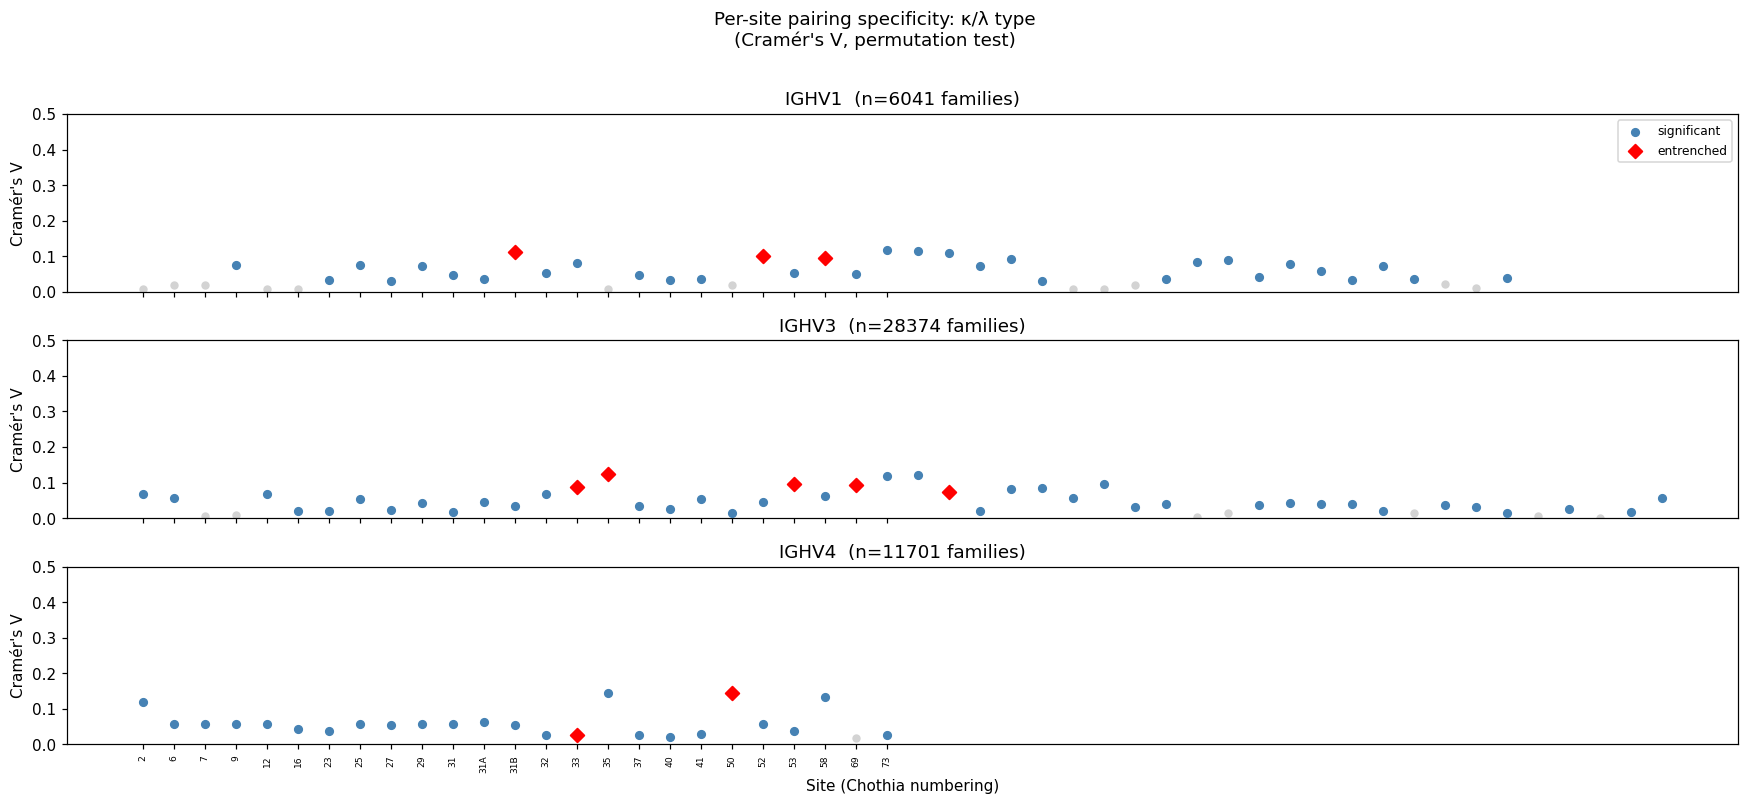

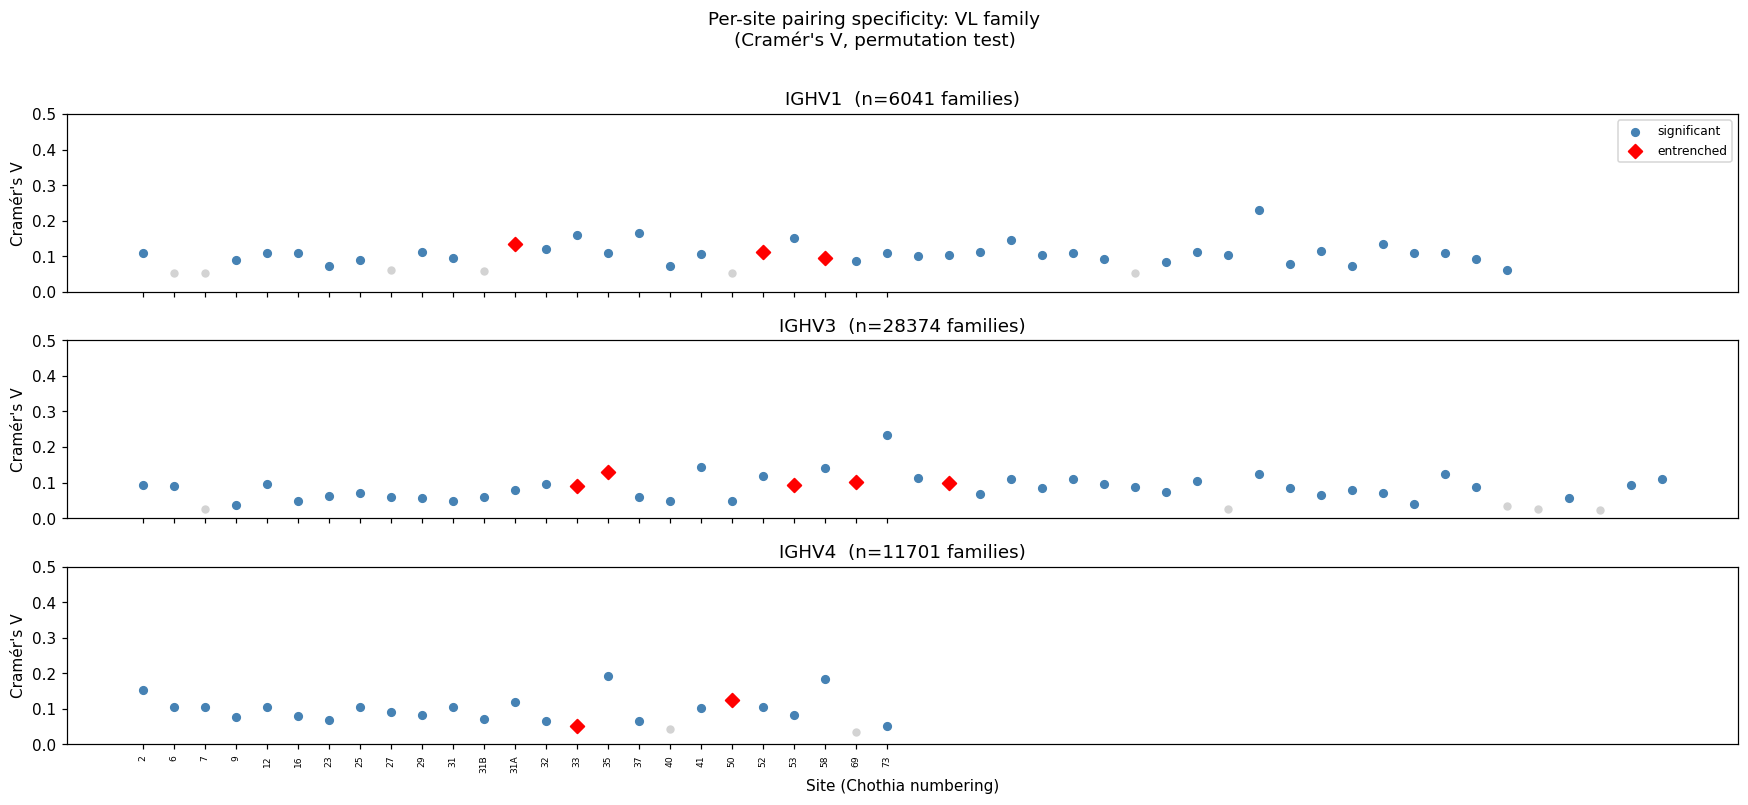

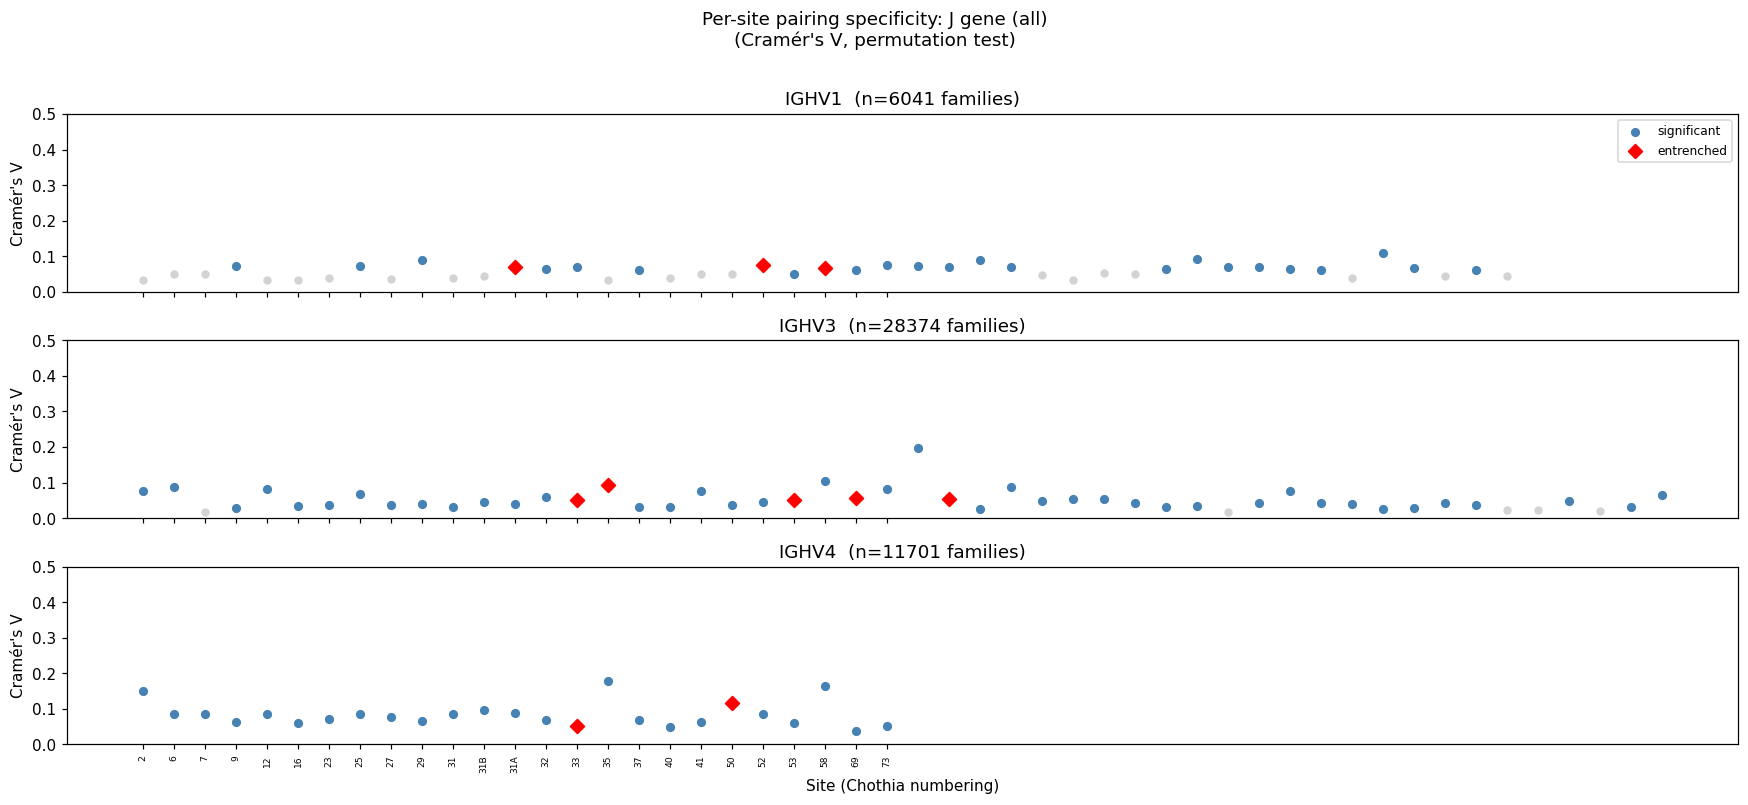

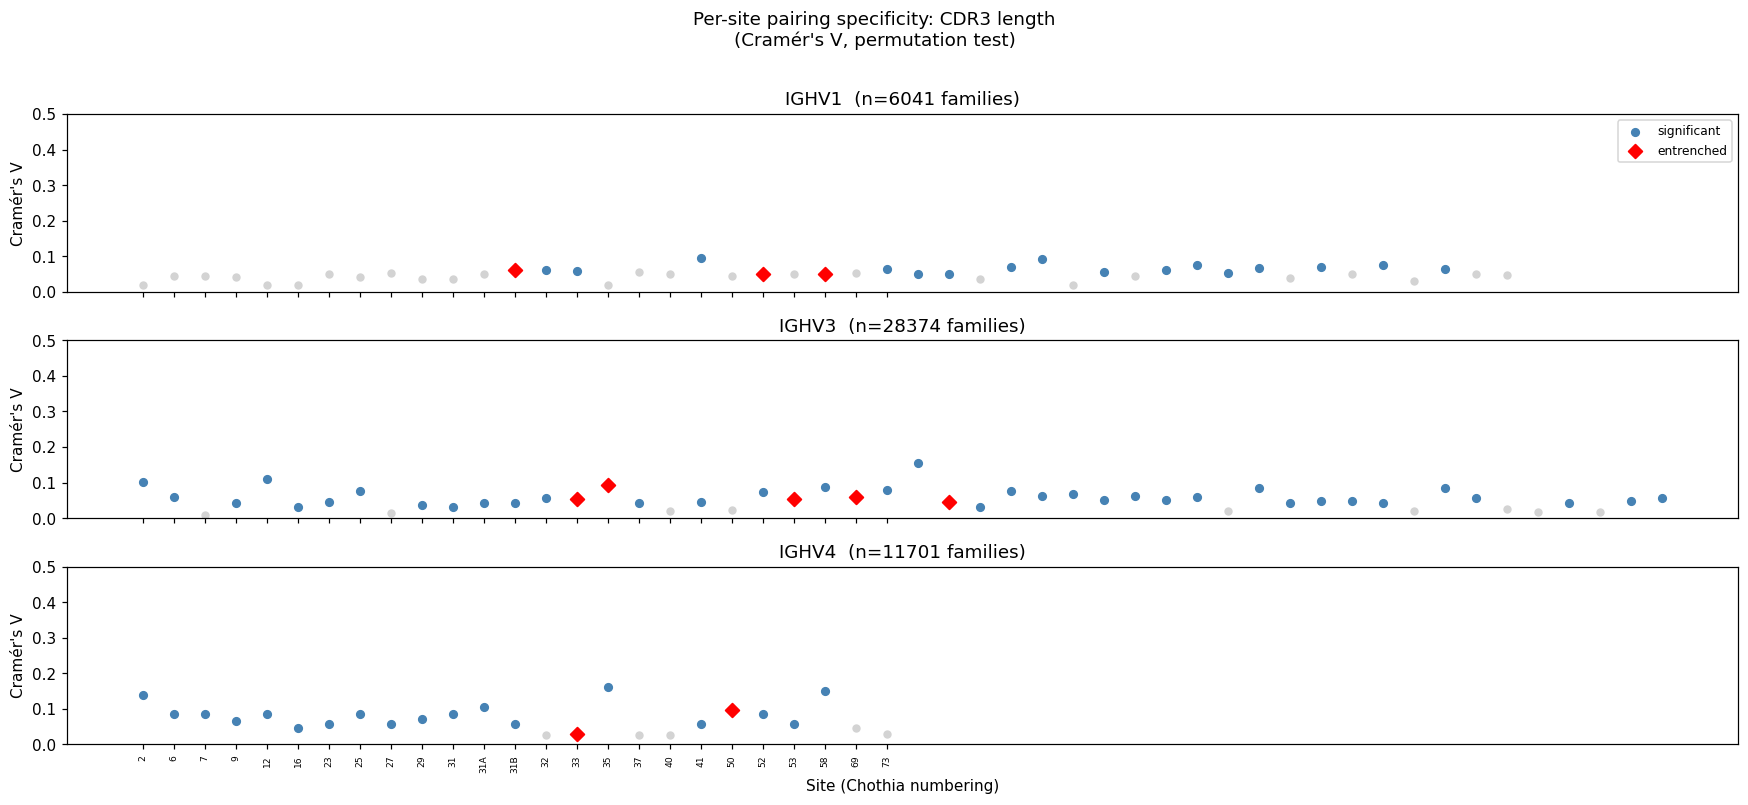

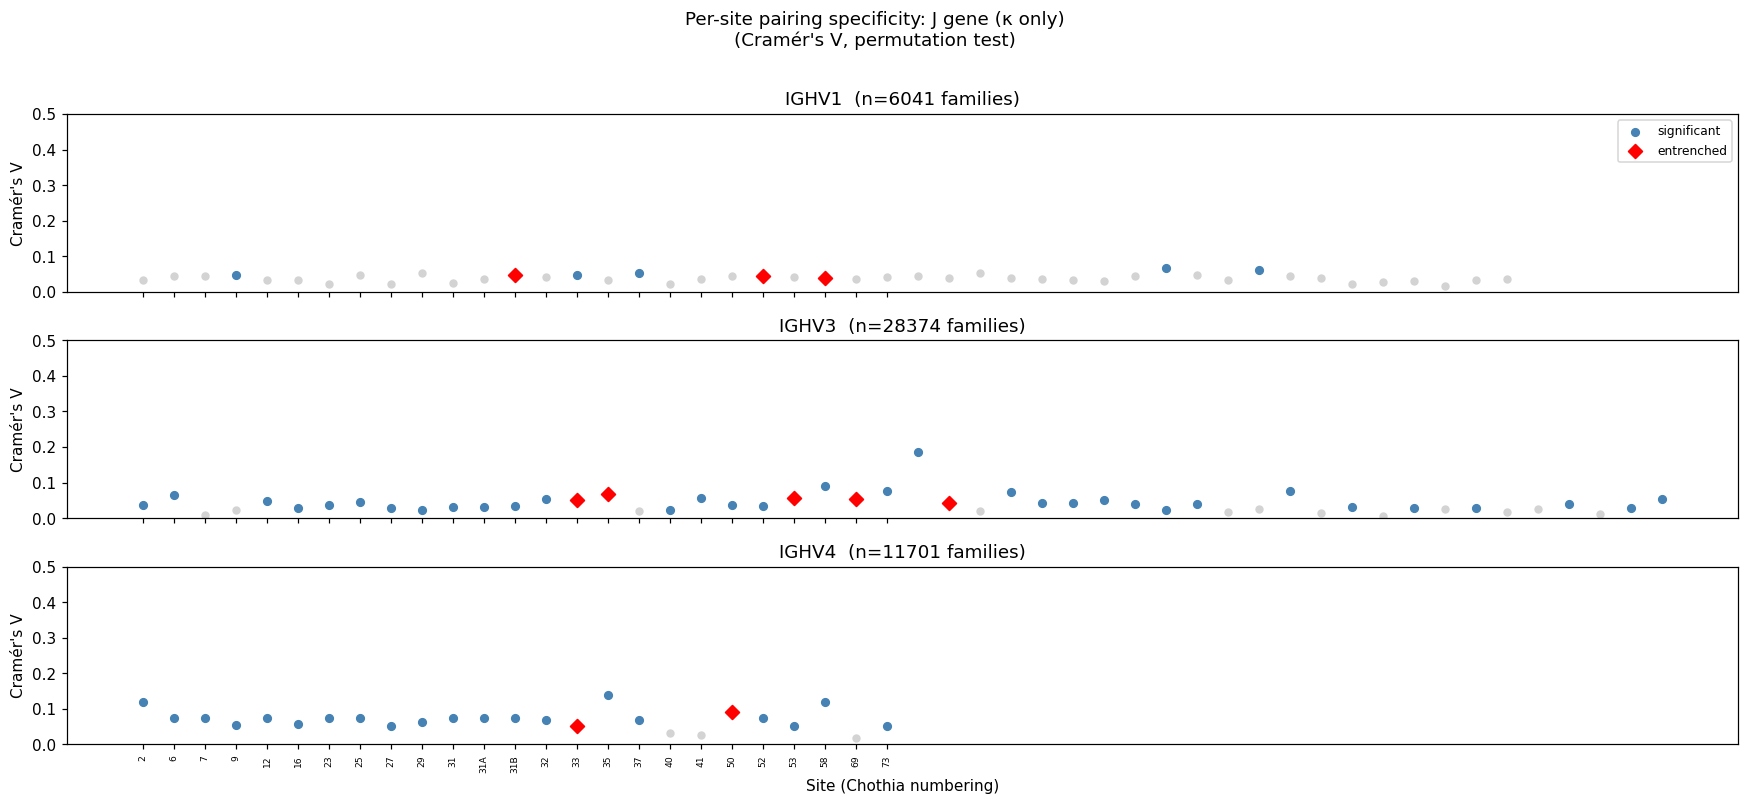

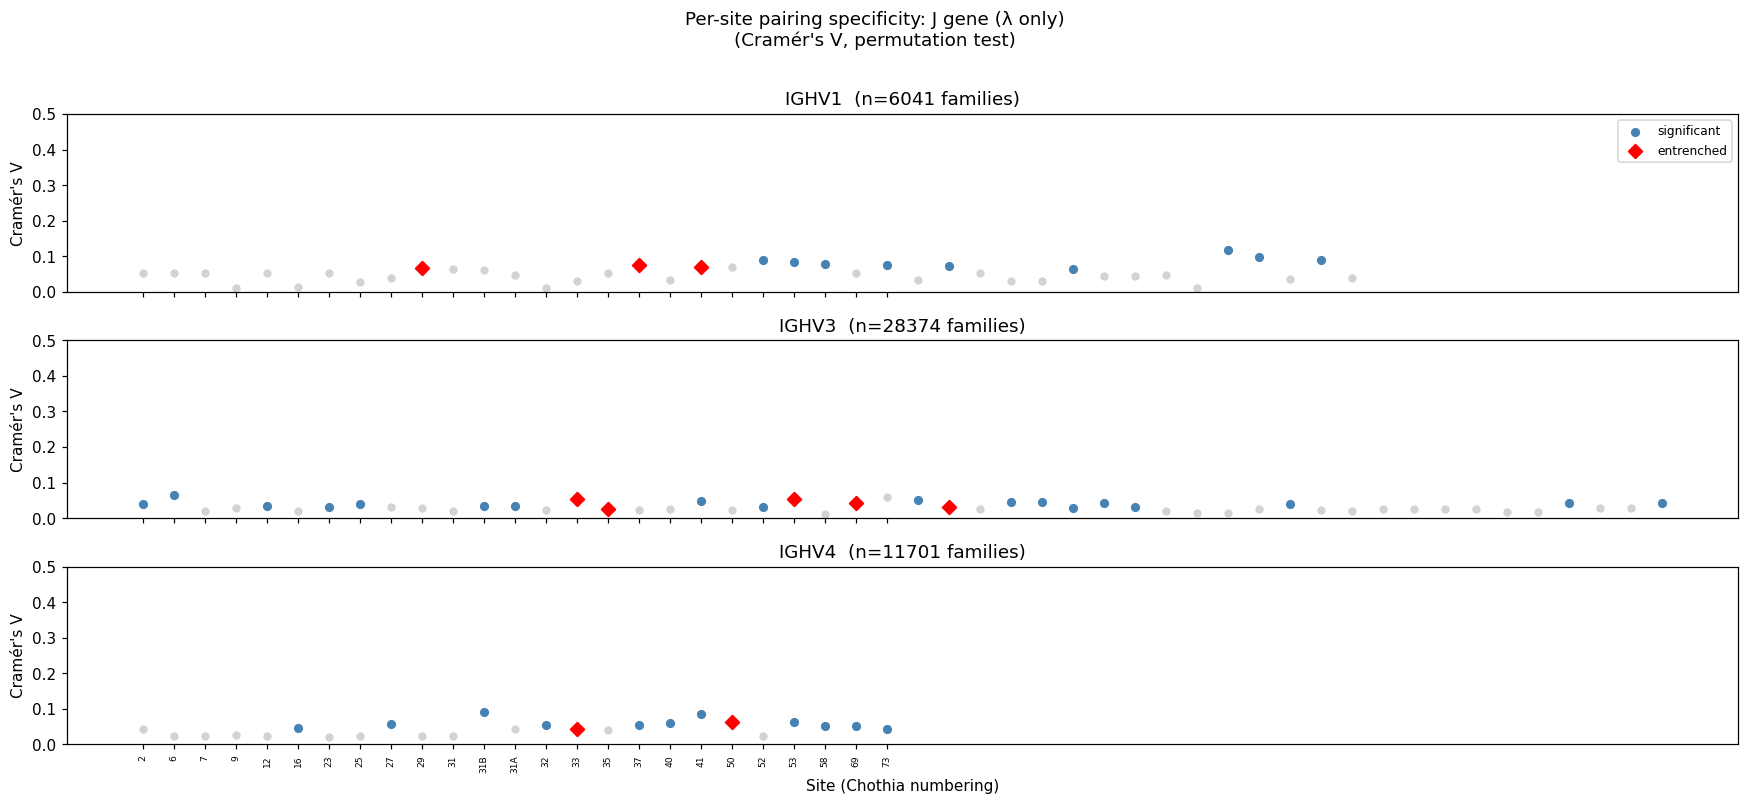

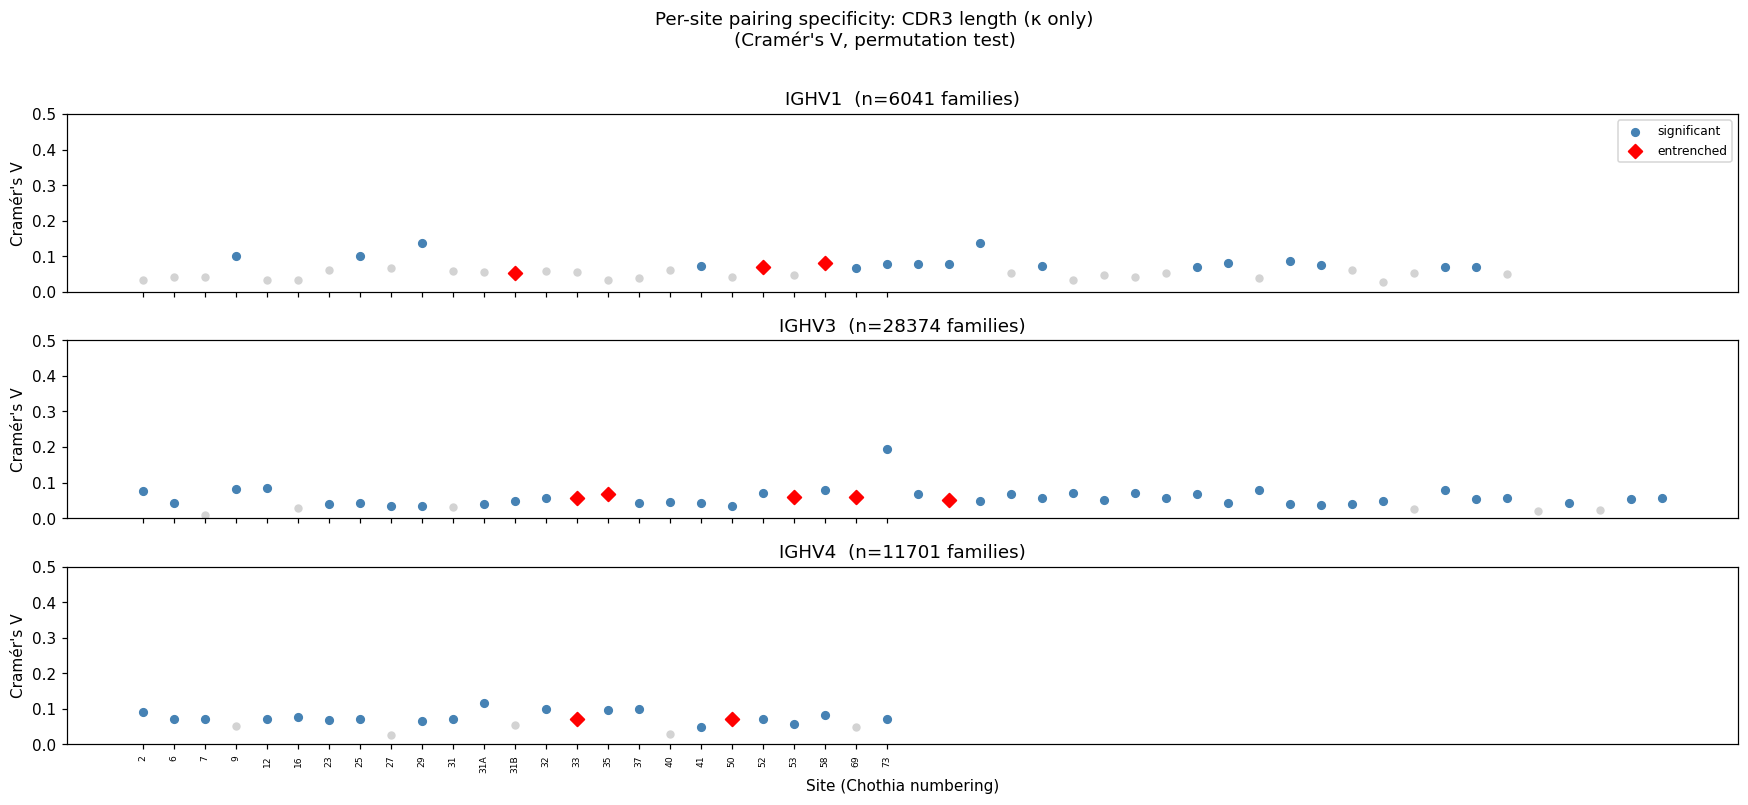

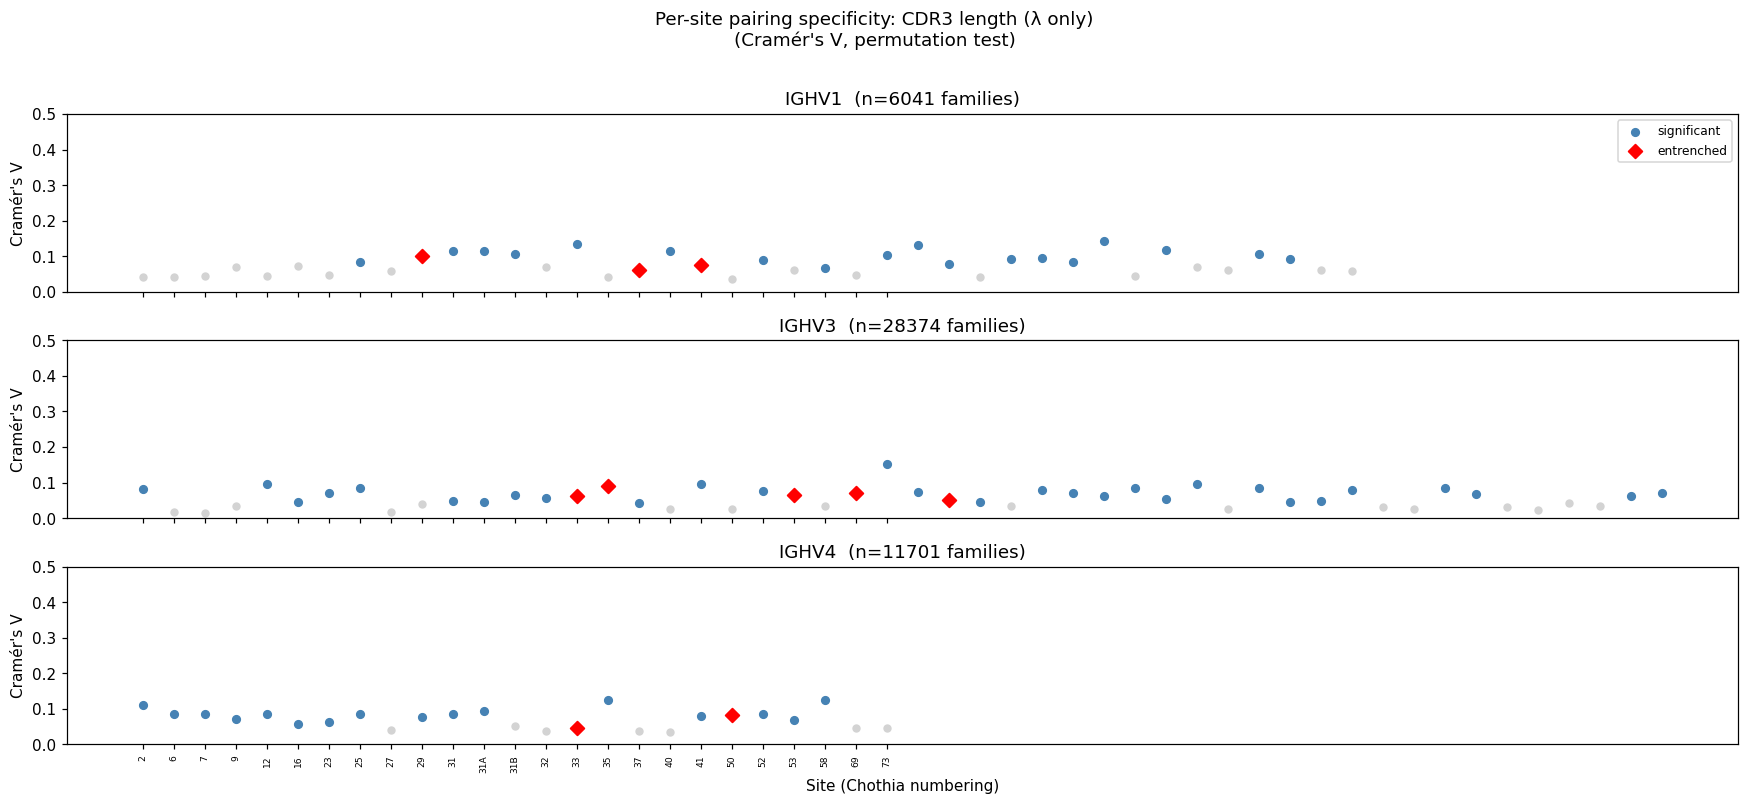

In [6]:
# Along-gene plots for all descriptors in scan_results

nice_names = {
    'lc_type': '\u03ba/\u03bb type',
    'vl_family': 'VL family',
    'j_gene_light': 'J gene (all)',
    'cdr3_len': 'CDR3 length',
    'j_gene_kappa': 'J gene (\u03ba only)',
    'j_gene_lambda': 'J gene (\u03bb only)',
    'cdr3_len_kappa': 'CDR3 length (\u03ba only)',
    'cdr3_len_lambda': 'CDR3 length (\u03bb only)',
}

for desc_name, df in scan_results.items():
    if len(df) == 0:
        continue

    v_families_here = sorted(df['v_family'].unique())
    fig, axes = plt.subplots(len(v_families_here), 1,
                              figsize=(16, 2.4 * len(v_families_here)),
                              sharex=True)
    if len(v_families_here) == 1:
        axes = [axes]

    for ax_i, (ax, vf) in enumerate(zip(axes, v_families_here)):
        sub = df[df.v_family == vf].copy()
        # Convert sites to numeric for x-axis positioning
        def site_sort_key(s):
            try:
                return float(s)
            except ValueError:
                # Handle sites like '52A' -> 52.5
                num = ''.join(c for c in s if c.isdigit())
                return float(num) + 0.5 if num else 999

        sub = sub.sort_values('site', key=lambda s: s.map(site_sort_key))
        xs = sub['site'].values
        ys = sub['cramers_v'].values
        is_sig = (sub['p_bh'].fillna(1.0) < 0.05).to_numpy(dtype=bool)
        is_ent = np.array(
            [(s, vf) in entrenched_pairs for s in sub['site']], dtype=bool
        )

        xs_arr = np.arange(len(xs))
        # Non-significant
        ax.scatter(xs_arr[~is_sig], ys[~is_sig],
                   color='lightgrey', s=20, zorder=2)
        # Significant
        ax.scatter(xs_arr[is_sig & ~is_ent], ys[is_sig & ~is_ent],
                   color='steelblue', s=25, zorder=3, label='significant')
        # Entrenched
        if is_ent.any():
            ax.scatter(xs_arr[is_ent], ys[is_ent],
                       color='red', marker='D', s=40, zorder=4,
                       linewidth=1.2, label='entrenched')
        ax.set_ylabel("Cram\u00e9r's V")
        ax.set_title(f'{vf}  (n={int((families.v_family == vf).sum())} families)')
        ax.set_ylim(0, max(0.5, ys.max() * 1.1) if len(ys) else 0.5)
        if ax_i == 0:
            ax.legend(loc='upper right', fontsize=8)

        # Site labels on x-axis
        ax.set_xticks(xs_arr)
        ax.set_xticklabels(xs, rotation=90, fontsize=6)

    axes[-1].set_xlabel('Site (Chothia numbering)')
    nn = nice_names.get(desc_name, desc_name)
    fig.suptitle(f'Per-site pairing specificity: {nn}\n(Cram\u00e9r\'s V, permutation test)', y=1.01)
    plt.tight_layout()
    plt.show()

## 4. Entrenched-site overlap

Check whether entrenched (site, V family) pairs from the entrenchment analysis
show up among the significant pairing-bias hits in each scan.

In [7]:
print("=== Entrenched site overlap with per-site scans ===")

for desc_name, df in scan_results.items():
    if len(df) == 0:
        continue
    df['is_entrenched'] = [
        (s, vf) in entrenched_pairs
        for s, vf in zip(df['site'], df['v_family'])
    ]
    ent_sub = df[df.is_entrenched]
    if len(ent_sub) == 0:
        print(f"{desc_name}: no entrenched sites in scan")
        continue
    n_sig = (ent_sub['p_bh'] < 0.05).sum()
    nn = nice_names.get(desc_name, desc_name)
    print(f"\n{nn}:")
    print(f"  Entrenched (site, V family) in scan: {len(ent_sub)}")
    print(f"  BH<0.05: {n_sig}/{len(ent_sub)}")
    print(ent_sub[['v_family', 'site', 'cramers_v', 'p_perm', 'p_bh']]
          .sort_values('p_perm').round(4).to_string(index=False))

=== Entrenched site overlap with per-site scans ===

κ/λ type:
  Entrenched (site, V family) in scan: 10
  BH<0.05: 10/10
v_family site  cramers_v  p_perm   p_bh
   IGHV1   33     0.1115   0.001 0.0016
   IGHV1   50     0.0997   0.001 0.0016
   IGHV1   52     0.0955   0.001 0.0016
   IGHV3   33     0.0874   0.001 0.0016
   IGHV3   35     0.1230   0.001 0.0016
   IGHV4   50     0.1454   0.001 0.0016
   IGHV3   53     0.0726   0.001 0.0016
   IGHV3   52     0.0925   0.001 0.0016
   IGHV3   50     0.0966   0.001 0.0016
   IGHV4   33     0.0271   0.015 0.0198

VL family:
  Entrenched (site, V family) in scan: 10
  BH<0.05: 10/10
v_family site  cramers_v  p_perm   p_bh
   IGHV1   33     0.1355   0.001 0.0013
   IGHV1   52     0.0960   0.001 0.0013
   IGHV1   50     0.1105   0.001 0.0013
   IGHV3   33     0.0912   0.001 0.0013
   IGHV3   35     0.1287   0.001 0.0013
   IGHV3   53     0.0990   0.001 0.0013
   IGHV3   52     0.1006   0.001 0.0013
   IGHV3   50     0.0921   0.001 0.0013
   IGHV

## 5. Per-comparison-pair analysis: Cramér's V for all LC descriptors

For each entrenched vs non-entrenched AA pair from the entrenchment analysis, compute
Cramér's V on the 2×k table (AA1 vs AA2) × (LC descriptor categories). Compare effect
sizes and significance rates between entrenched and non-entrenched pairs.

This includes κ/λ as a descriptor (2×2 table per pair), alongside the finer-grained
descriptors.

In [8]:
def pair_cramers_v(fams_vf, site, aa1, aa2, lc_col, min_n=10):
    """
    For a pair of germline AAs at a site, compute Cram\u00e9r's V on the
    2\u00d7k table (AA1 vs AA2) \u00d7 (LC descriptor categories).
    """
    germ_col = f'germ_{site}'
    if germ_col not in fams_vf.columns:
        return None
    sub = fams_vf[fams_vf[germ_col].isin([aa1, aa2])][[germ_col, lc_col]].dropna()
    if len(sub) < 2 * min_n:
        return None

    ctab = pd.crosstab(sub[germ_col], sub[lc_col])
    if aa1 not in ctab.index or aa2 not in ctab.index:
        return None
    ctab = ctab.loc[[aa1, aa2]]
    ctab = ctab.loc[:, ctab.sum(axis=0) >= min_n]
    if ctab.shape[1] < 2:
        return None

    try:
        v = cramers_v(ctab.values)
        chi2, p_chi2 = chi2_contingency(ctab.values)[:2]
    except (ValueError, ZeroDivisionError):
        return None

    return {'cramers_v': v, 'chi2': chi2, 'p_chi2': p_chi2,
            'n_cats': ctab.shape[1], 'n_total': int(ctab.values.sum())}


# Run for each LC descriptor (including lc_type for \u03ba/\u03bb)
VFAMILIES_ANALYSIS = ['IGHV1', 'IGHV3']
lc_cols_to_test = {
    'lc_type': {'col': 'light_chain_type', 'min_n': 10, 'subset': None},
    'vl_family': {'col': 'vl_family', 'min_n': 10, 'subset': None},
    'j_gene_light': {'col': 'j_gene_light', 'min_n': 10, 'subset': None},
    'j_gene_kappa': {'col': 'j_gene_light', 'min_n': 10, 'subset': 'kappa'},
    'j_gene_lambda': {'col': 'j_gene_light', 'min_n': 10, 'subset': 'lambda'},
    'cdr3_len': {'col': 'cdr3_len', 'min_n': 10, 'subset': None},
    'cdr3_len_kappa': {'col': 'cdr3_len', 'min_n': 10, 'subset': 'kappa'},
    'cdr3_len_lambda': {'col': 'cdr3_len', 'min_n': 10, 'subset': 'lambda'},
}

results_by_desc = {}
for desc_name, desc_info in lc_cols_to_test.items():
    lc_col = desc_info['col']
    min_n = desc_info['min_n']
    lc_subset = desc_info['subset']

    pair_rows = []
    for _, row in comp.iterrows():
        vf = row['v_family']
        if vf not in VFAMILIES_ANALYSIS:
            continue
        vf_fams = families[families.v_family == vf]
        if lc_subset is not None:
            vf_fams = vf_fams[vf_fams.light_chain_type == lc_subset]

        result = pair_cramers_v(vf_fams, row['site'], row['aa1'], row['aa2'],
                                lc_col, min_n=min_n)
        if result is None:
            continue
        pair_rows.append({
            'v_family': vf,
            'site': row['site'],
            'aa1': row['aa1'],
            'aa2': row['aa2'],
            'is_entrenched': row['is_entrenched'],
            **result,
        })

    pdf = pd.DataFrame(pair_rows)
    if len(pdf) == 0:
        print(f"{desc_name}: no valid pairs")
        continue

    # BH correction on chi2 p-values
    valid = pdf['p_chi2'].notna()
    pdf['p_bh'] = np.nan
    if valid.sum() > 0:
        _, bh, _, _ = multipletests(pdf.loc[valid, 'p_chi2'], method='fdr_bh')
        pdf.loc[valid, 'p_bh'] = bh
    pdf['sig'] = pdf['p_bh'] < 0.05

    results_by_desc[desc_name] = pdf

    # Summarize
    ent = pdf[pdf.is_entrenched]
    non = pdf[~pdf.is_entrenched]
    print(f"\n{'='*60}")
    print(f"LC descriptor: {desc_name}")
    print(f"{'='*60}")
    print(f"  Pairs: {len(pdf)} (entrenched: {len(ent)}, non: {len(non)})")
    if len(ent) > 0 and len(non) > 0:
        print(f"  Cram\u00e9r's V mean:   ent={ent['cramers_v'].mean():.4f}, non={non['cramers_v'].mean():.4f}")
        print(f"  Cram\u00e9r's V median: ent={ent['cramers_v'].median():.4f}, non={non['cramers_v'].median():.4f}")
        _, mw_p = mannwhitneyu(ent['cramers_v'], non['cramers_v'], alternative='greater')
        print(f"  Mann-Whitney (ent > non): p={mw_p:.4f}")

        es = ent['sig'].sum()
        en = len(ent) - es
        ns = non['sig'].sum()
        nn_ = len(non) - ns
        if (es + en) > 0 and (ns + nn_) > 0:
            or_val, fp = fisher_exact([[es, en], [ns, nn_]], alternative='greater')
            print(f"  Significance rates: ent={es}/{es+en} ({100*es/(es+en):.0f}%), "
                  f"non={ns}/{ns+nn_} ({100*ns/(ns+nn_):.0f}%)")
            print(f"  Fisher's exact: OR={or_val:.2f}, p={fp:.4f}")


LC descriptor: lc_type
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.0614, non=0.0468
  Cramér's V median: ent=0.0621, non=0.0345
  Mann-Whitney (ent > non): p=0.0523
  Significance rates: ent=14/19 (74%), non=123/202 (61%)
  Fisher's exact: OR=1.80, p=0.1990



LC descriptor: vl_family
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.1777, non=0.1288
  Cramér's V median: ent=0.1404, non=0.1179
  Mann-Whitney (ent > non): p=0.0100
  Significance rates: ent=19/19 (100%), non=179/202 (89%)
  Fisher's exact: OR=inf, p=0.1126



LC descriptor: j_gene_light
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.1078, non=0.0828
  Cramér's V median: ent=0.0813, non=0.0725
  Mann-Whitney (ent > non): p=0.0145
  Significance rates: ent=16/19 (84%), non=143/202 (71%)
  Fisher's exact: OR=2.20, p=0.1645



LC descriptor: j_gene_kappa
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.0854, non=0.0612
  Cramér's V median: ent=0.0729, non=0.0474
  Mann-Whitney (ent > non): p=0.0082
  Significance rates: ent=8/19 (42%), non=82/202 (41%)
  Fisher's exact: OR=1.06, p=0.5410



LC descriptor: j_gene_lambda
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.0572, non=0.0530
  Cramér's V median: ent=0.0424, non=0.0391
  Mann-Whitney (ent > non): p=0.4678
  Significance rates: ent=2/19 (11%), non=44/202 (22%)
  Fisher's exact: OR=0.42, p=0.9373



LC descriptor: cdr3_len
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.0986, non=0.0739
  Cramér's V median: ent=0.0820, non=0.0653
  Mann-Whitney (ent > non): p=0.0176
  Significance rates: ent=12/19 (63%), non=121/202 (60%)
  Fisher's exact: OR=1.15, p=0.4929



LC descriptor: cdr3_len_kappa
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.1083, non=0.0769
  Cramér's V median: ent=0.0971, non=0.0664
  Mann-Whitney (ent > non): p=0.0020
  Significance rates: ent=14/19 (74%), non=130/202 (64%)
  Fisher's exact: OR=1.55, p=0.2921



LC descriptor: cdr3_len_lambda
  Pairs: 221 (entrenched: 19, non: 202)
  Cramér's V mean:   ent=0.0944, non=0.0850
  Cramér's V median: ent=0.0718, non=0.0788
  Mann-Whitney (ent > non): p=0.4344
  Significance rates: ent=8/19 (42%), non=96/202 (48%)
  Fisher's exact: OR=0.80, p=0.7546


In [9]:
# Summary table across all LC descriptors
print("\n" + "="*70)
print("SUMMARY: Entrenched vs non-entrenched across LC descriptors")
print("="*70)
print(f"{'Descriptor':<20} {'N pairs':<10} {'V(ent)':<10} {'V(non)':<10} {'MW p':<10} "
      f"{'Sig%(ent)':<10} {'Sig%(non)':<10} {'Fisher p':<10}")
print("-"*90)

for desc_name, pdf in results_by_desc.items():
    ent = pdf[pdf.is_entrenched]
    non = pdf[~pdf.is_entrenched]
    if len(ent) == 0 or len(non) == 0:
        continue
    _, mw_p = mannwhitneyu(ent['cramers_v'], non['cramers_v'], alternative='greater')
    es = ent['sig'].sum()
    ns = non['sig'].sum()
    or_val, fp = fisher_exact(
        [[es, len(ent)-es], [ns, len(non)-ns]], alternative='greater')
    print(f"{desc_name:<20} {len(pdf):<10} {ent['cramers_v'].median():<10.4f} "
          f"{non['cramers_v'].median():<10.4f} {mw_p:<10.4f} "
          f"{100*es/len(ent):<10.0f} {100*ns/len(non):<10.0f} {fp:<10.4f}")


SUMMARY: Entrenched vs non-entrenched across LC descriptors
Descriptor           N pairs    V(ent)     V(non)     MW p       Sig%(ent)  Sig%(non)  Fisher p  
------------------------------------------------------------------------------------------
lc_type              221        0.0621     0.0345     0.0523     74         61         0.1990    
vl_family            221        0.1404     0.1179     0.0100     100        89         0.1126    
j_gene_light         221        0.0813     0.0725     0.0145     84         71         0.1645    
j_gene_kappa         221        0.0729     0.0474     0.0082     42         41         0.5410    
j_gene_lambda        221        0.0424     0.0391     0.4678     11         22         0.9373    
cdr3_len             221        0.0820     0.0653     0.0176     63         60         0.4929    
cdr3_len_kappa       221        0.0971     0.0664     0.0020     74         64         0.2921    
cdr3_len_lambda      221        0.0718     0.0788     0.4344    

In [10]:
# Restricted analysis: only pairs at entrenched sites (same-site control)
print("\n" + "="*70)
print("RESTRICTED TO ENTRENCHED SITES ONLY (same-site control)")
print("="*70)
print(f"{'Descriptor':<20} {'N pairs':<10} {'V(ent)':<10} {'V(non)':<10} {'MW p':<10} "
      f"{'Sig%(ent)':<10} {'Sig%(non)':<10} {'Fisher p':<10}")
print("-"*90)

for desc_name, pdf in results_by_desc.items():
    ent_sites = set(zip(
        pdf.loc[pdf.is_entrenched, 'site'],
        pdf.loc[pdf.is_entrenched, 'v_family'],
    ))
    at_ent = pdf[pdf.apply(lambda r: (r['site'], r['v_family']) in ent_sites, axis=1)]
    ent = at_ent[at_ent.is_entrenched]
    non = at_ent[~at_ent.is_entrenched]
    if len(ent) == 0 or len(non) == 0:
        continue
    _, mw_p = mannwhitneyu(ent['cramers_v'], non['cramers_v'], alternative='greater')
    es = ent['sig'].sum()
    ns = non['sig'].sum()
    or_val, fp = fisher_exact(
        [[es, len(ent)-es], [ns, len(non)-ns]], alternative='greater')
    print(f"{desc_name:<20} {len(at_ent):<10} {ent['cramers_v'].median():<10.4f} "
          f"{non['cramers_v'].median():<10.4f} {mw_p:<10.4f} "
          f"{100*es/len(ent):<10.0f} {100*ns/len(non):<10.0f} {fp:<10.4f}")


RESTRICTED TO ENTRENCHED SITES ONLY (same-site control)
Descriptor           N pairs    V(ent)     V(non)     MW p       Sig%(ent)  Sig%(non)  Fisher p  
------------------------------------------------------------------------------------------
lc_type              58         0.0621     0.0521     0.4736     74         69         0.4892    
vl_family            58         0.1404     0.1325     0.1371     100        97         0.6724    
j_gene_light         58         0.0813     0.0972     0.5198     84         72         0.2428    
j_gene_kappa         58         0.0729     0.0743     0.3640     42         44         0.6498    
j_gene_lambda        58         0.0424     0.0494     0.7567     11         18         0.8703    
cdr3_len             58         0.0820     0.0896     0.4604     63         72         0.8341    
cdr3_len_kappa       58         0.0971     0.0789     0.1040     74         67         0.4106    
cdr3_len_lambda      58         0.0718     0.0891     0.8189     42 

In [11]:
# Show entrenched pairs for key descriptors
for desc_name in ['lc_type', 'vl_family', 'j_gene_kappa', 'j_gene_lambda', 'cdr3_len_kappa']:
    if desc_name not in results_by_desc:
        continue
    pdf = results_by_desc[desc_name]
    ent = pdf[pdf.is_entrenched].sort_values('cramers_v', ascending=False)
    if len(ent) == 0:
        continue
    print(f"\n--- {desc_name}: entrenched pairs ---")
    print(ent[['v_family', 'site', 'aa1', 'aa2', 'cramers_v', 'n_cats',
               'n_total', 'p_chi2', 'p_bh', 'sig']].round(4).to_string(index=False))


--- lc_type: entrenched pairs ---
v_family site aa1 aa2  cramers_v  n_cats  n_total  p_chi2   p_bh   sig
   IGHV3   35   D   N     0.1649       2     4545  0.0000 0.0000  True
   IGHV3   35   D   H     0.1369       2     9249  0.0000 0.0000  True
   IGHV1   33   A   D     0.1083       2     2217  0.0000 0.0000  True
   IGHV3   52   G   R     0.0976       2     2174  0.0000 0.0000  True
   IGHV1   33   D   G     0.0848       2     1654  0.0006 0.0013  True
   IGHV1   50   G   W     0.0758       2     4303  0.0000 0.0000  True
   IGHV1   33   S   Y     0.0721       2     2425  0.0004 0.0009  True
   IGHV3   53   D   Y     0.0715       2    13142  0.0000 0.0000  True
   IGHV1   52   I   S     0.0689       2     2116  0.0015 0.0032  True
   IGHV3   33   D   Y     0.0621       2     3217  0.0004 0.0010  True
   IGHV3   52   R   S     0.0523       2    17453  0.0000 0.0000  True
   IGHV3   50   N   Y     0.0502       2     7480  0.0000 0.0000  True
   IGHV3   50   S   Y     0.0336       2  

## 6. Multi-panel effect-size plots

Per-pair Cramér's V at entrenched sites, comparing entrenched (black) vs non-entrenched
(grey) AA pairs. One figure per LC descriptor.

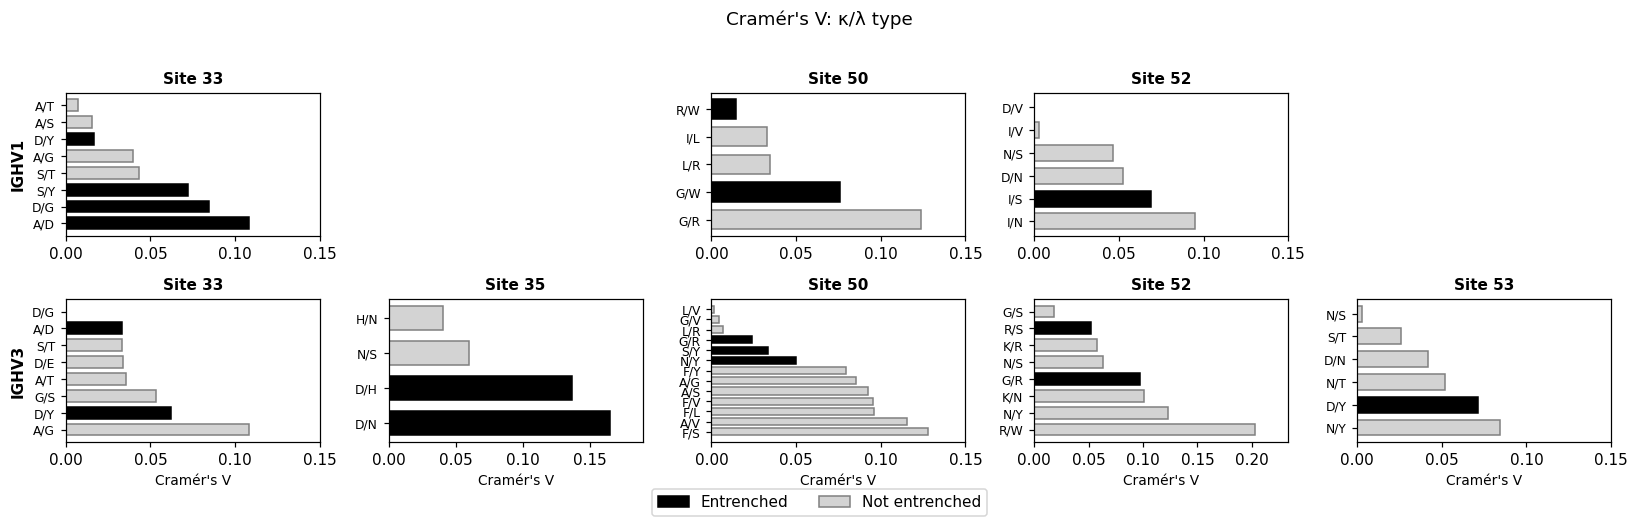

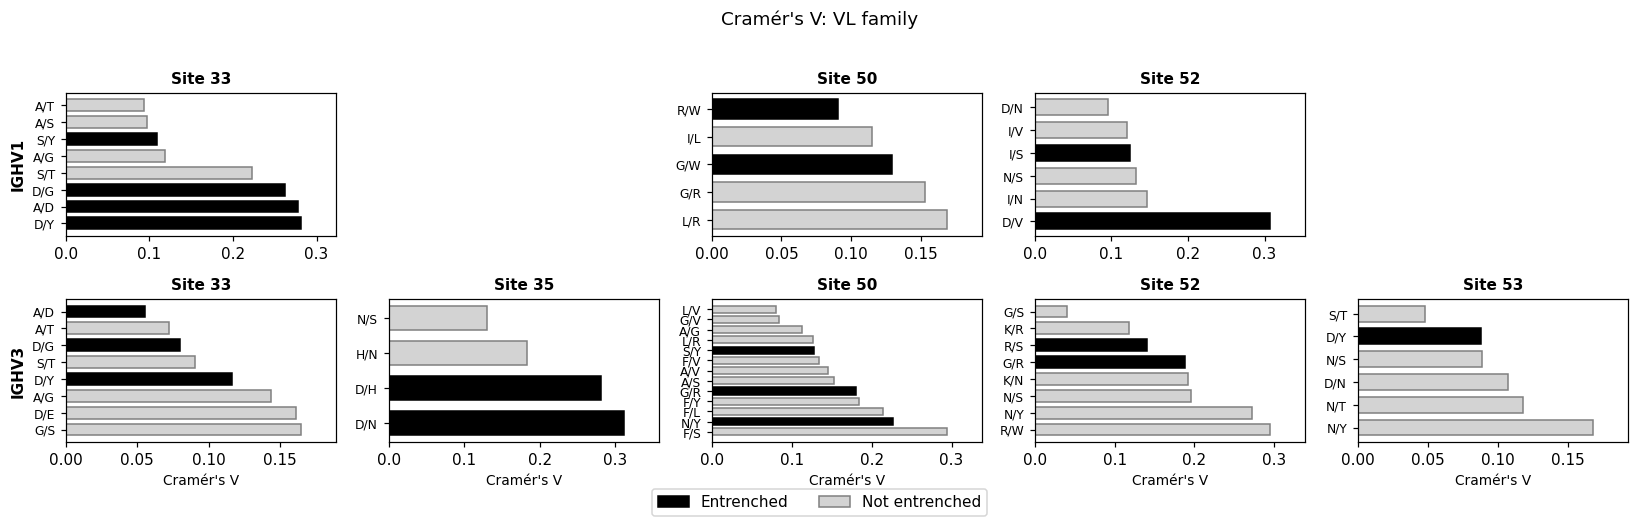

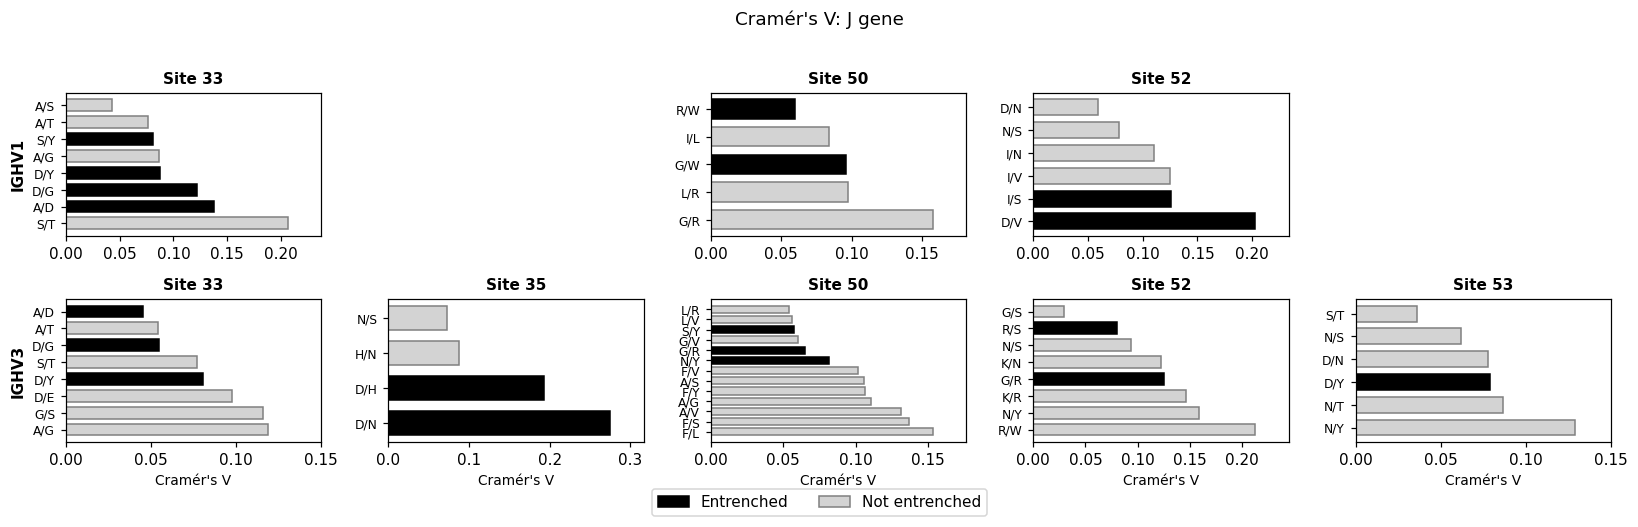

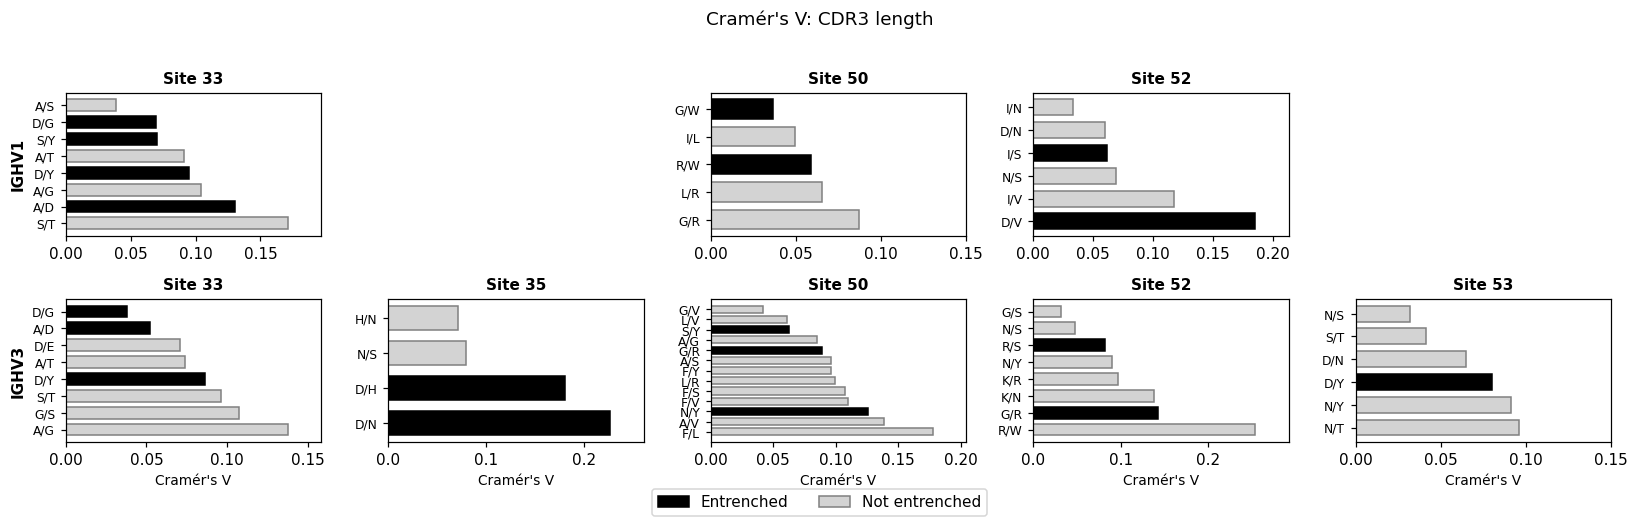

In [12]:
from matplotlib.patches import Patch

vfamilies_show = ['IGHV1', 'IGHV3']

# Build plot specs: all descriptors use Cram\u00e9r's V
plot_specs = []
for desc_name, nn in [('lc_type', '\u03ba/\u03bb type'),
                       ('vl_family', 'VL family'),
                       ('j_gene_light', 'J gene'),
                       ('cdr3_len', 'CDR3 length')]:
    if desc_name in results_by_desc:
        plot_specs.append((f"Cram\u00e9r's V: {nn}", results_by_desc[desc_name], 'cramers_v', "Cram\u00e9r's V"))

for title, pdf_plot, val_col, xlabel in plot_specs:
    # Restrict to entrenched sites in IGHV1/IGHV3
    pdf_sub = pdf_plot[pdf_plot.v_family.isin(vfamilies_show)].copy()
    ent_sites_here = set(zip(
        pdf_sub.loc[pdf_sub.is_entrenched, 'site'],
        pdf_sub.loc[pdf_sub.is_entrenched, 'v_family'],
    ))
    if not ent_sites_here:
        continue
    sites_here = sorted(
        set(s for s, _ in ent_sites_here),
        key=lambda s: (int(s) if s.isdigit() else float('inf'), s)
    )

    fig, axes = plt.subplots(
        len(vfamilies_show), len(sites_here),
        figsize=(3.0 * len(sites_here), 2.2 * len(vfamilies_show)),
        squeeze=False,
    )

    for col_i, site in enumerate(sites_here):
        for row_i, vf in enumerate(vfamilies_show):
            ax = axes[row_i, col_i]

            if (site, vf) not in ent_sites_here:
                ax.set_visible(False)
                continue

            sub = pdf_sub[(pdf_sub.site == site) & (pdf_sub.v_family == vf)]
            sub = sub.sort_values(val_col, ascending=False)
            labels = [f"{r.aa1}/{r.aa2}" for _, r in sub.iterrows()]
            colors = ['black' if r.is_entrenched else 'lightgrey' for _, r in sub.iterrows()]
            edge_colors = ['black' if r.is_entrenched else 'grey' for _, r in sub.iterrows()]

            y = np.arange(len(sub))
            ax.barh(y, sub[val_col], color=colors, edgecolor=edge_colors, height=0.7)
            ax.set_yticks(y)
            ax.set_yticklabels(labels, fontsize=8)
            xmax = sub[val_col].max()
            ax.set_xlim(0, max(0.15, xmax * 1.15) if xmax > 0 else 0.15)

            # Site title on EVERY subplot
            ax.set_title(f"Site {site}", fontweight='bold', fontsize=10)
            if col_i == 0:
                ax.set_ylabel(vf, fontweight='bold', fontsize=10)
            if row_i == len(vfamilies_show) - 1:
                ax.set_xlabel(xlabel, fontsize=9)

    legend_elements = [
        Patch(facecolor='black', edgecolor='black', label='Entrenched'),
        Patch(facecolor='lightgrey', edgecolor='grey', label='Not entrenched'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()